# Setup

In [68]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import utils.stats as sts
import utils.plotting as plotting

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "font.family": "Lato",
    "ytick.direction": "in",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
    })

## Teste - Período Rotacional

$$v\sin(i) = \dfrac{2\pi R \sin(i)}{P} \Rightarrow i = \arcsin\left[\dfrac{(v\sin(i))P}{2\pi R}\right]$$

In [57]:
def calcular_inclinacao(row):
    vsini = row["vsini"]                 # km/s
    rotp = row["RotP"]                   # dias
    radius = row["radius_val"] * 6.96e5  # Converter raio solar para km
    
    # Converter período de dias para segundos
    P = rotp * 24 * 3600                # segundos
    
    # Calcular sin(i)
    sin_i = (vsini * P) / (2 * np.pi * radius)
    
    # Garantir que sin(i) está no intervalo válido [-1, 1]
    sin_i = min(1, max(sin_i, -1))
        
    return np.degrees(np.arcsin(sin_i))

# Importando os dados

In [56]:
gcs = pd.read_csv("../data/gcs-Fstars.csv")
periodos = pd.read_csv("../data/Fstars_with_periods.csv")
raios = pd.read_csv("../data/Fstars_with_radius_DR2.csv").rename(
    {"target_id": "Name"}, axis = 1)[["Name", "radius_val"]].drop_duplicates(subset="Name")

df = pd.merge(gcs, periodos, on="Name")
df = pd.merge(df, raios, on="Name")
df.shape, df.dropna(subset={"RotP", "radius_val"}, axis = 0).shape

((2869, 79), (2604, 79))

In [59]:
dados = df.dropna(subset={"RotP", "radius_val"}, axis = 0).copy()
dados["inclinacao"] = dados.apply(calcular_inclinacao, axis=1)

# Refazendo os passos agora para inclinação

In [61]:
x, y, i = dados["X"].values, dados["Y"].values, dados["inclinacao"].values

# Parâmetros fixos para análise
tc = 20     # Tamanho do quadrado (20 x 20) em pc
B = 1000    # Número de reamostragens (bootstrap)
ul = 150    # Valor para cobrir a área de lado 300 pc

# Intervalo para construir o espaço de análise
interval = 1
ttx = np.arange(-ul, ul + interval * tc, interval * tc)
tty = np.arange(-ul, ul + interval * tc, interval * tc)

# Número de intervalos ao longo de x e y
Nx = len(ttx) - 1
Ny = len(tty) - 1

# Percentual de corte para a média truncada
trimpct = 20

# Processamento principal dos dados
meanoriginal, boot_mean, boot_se, ci1, ci2, largura, shape, countfXY, sigma_distance = sts.process_data(ttx, tty, x, y, i, B, trimpct)

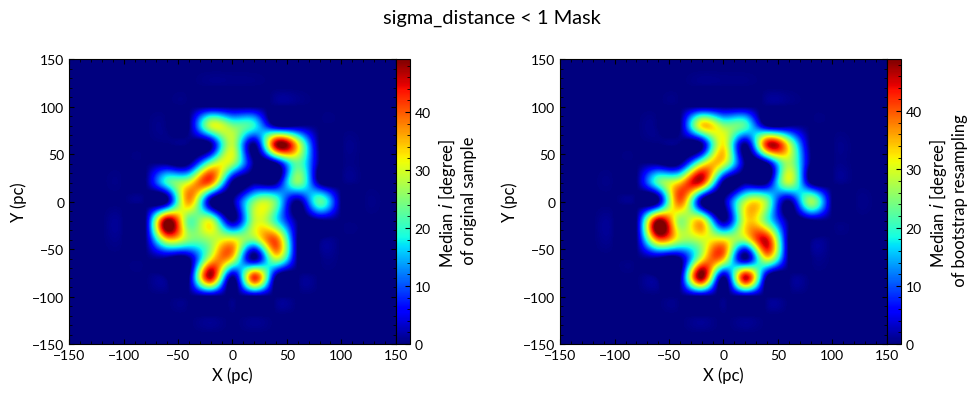

In [70]:
# Considerando que sigma_distance < 1 seja nosso critério
mask = sigma_distance < 1

# Plotagem dos resultados usando a máscara para filtrar dados
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots = [(meanoriginal * mask, 'Median $i$ [degree] \n of original sample'),
         (boot_mean * mask, 'Median $i$ [degree] \n of bootstrap resampling')]

for ax, (data, label) in zip(axs.flat, plots):
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet', interpolation=method, extent=(-ul, ul, -ul, ul))
    plt.suptitle("sigma_distance < 1 Mask")
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    cbar.set_label(label)
    
fig.tight_layout()
plt.show()

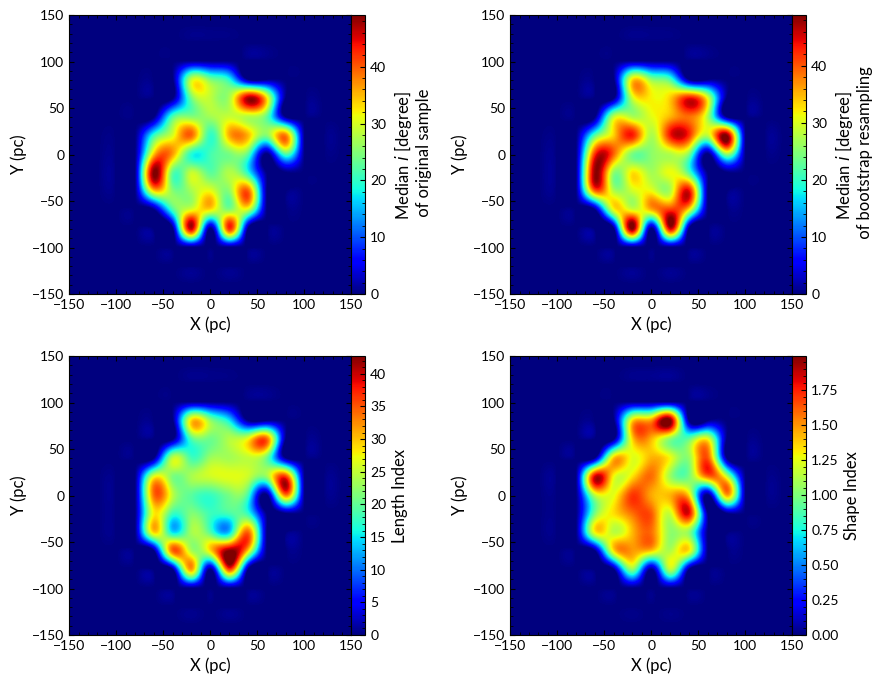

In [72]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
plots = [(meanoriginal, 'Median $i$ [degree] \n of original sample'),
         (boot_mean, 'Median $i$ [degree] \n of bootstrap resampling'),
         (largura, 'Length Index'),
         (shape, 'Shape Index')]

for ax, (data, label) in zip(axs.flat, plots):
    niter = 1
    method = 'spline36'
    im = ax.imshow(data, aspect='auto', cmap='jet',interpolation=method, extent=(-ul, ul, -ul, ul))
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    
    if ax == axs[0, 0]:
        cbar.set_label(label)
        cbar.formatter = plt.FuncFormatter(lambda x, _: f'{int(x):d}')
        cbar.update_ticks()
    else:
        cbar.set_label(label)
        
fig.tight_layout()
plt.show()